In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
#Constantes e Parâmetros

g = 9.81 #m/s²


In [30]:
def aceleracao(v, m, b, c, g=9.81):
    '''A função recebe os argumentos e retorna o vetor aceleração
    v: vetor velocidade (m/s)
    m: massa (kg)
    g: constante gravitacional (m/s²)
    b: coefienciente linear (kg/s)
    c: coeficiente quadrático(ks/m)

    retorna:
    a: vetor aceleração (m/s²)

    '''

    v_norma = np.linalg.norm(v)
    gravidade = np.array([0,-g]) # 0 no eixo x e "-g" no eixo y
    r_linear = -(b/m) * v
    r_quad = - (c/m)* v_norma * v

    a = gravidade + r_linear + r_quad
    return a

In [31]:

def euler(funcao_acel, r0, v0, t_array, m, b, c, g=9.81):

    n = len(t_array)

    r = np.zeros((n, 2)) 
    v = np.zeros((n, 2))
    
    r[0] = r0
    v[0] = v0
    
    for i in range(0, n - 1):
        dt = t_array[i+1] - t_array[i]
        a_atual = funcao_acel(v[i], m, b, c, g)
        r[i+1] = r[i] + v[i] * dt
        v[i+1] = v[i] + a_atual * dt
        
    return r, v

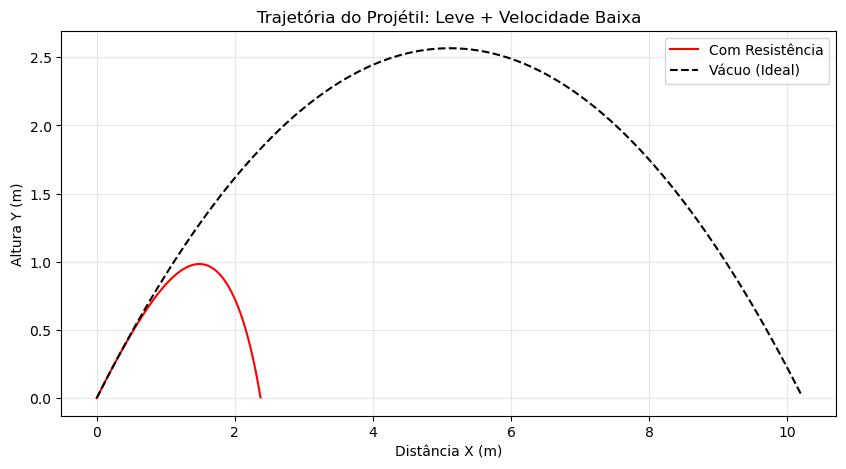

In [34]:
# --- Configuração do Cenário: Leve + Baixa Velocidade ---
m = 0.01          # kg (Leve)
b = 0.003        # kg/s
c = 0.005        # kg/m
v_mag = 10.0      # m/s (Baixa)
theta = np.deg2rad(45)

r0 = np.array([0.0, 0.0])
v0 = np.array([v_mag * np.cos(theta), v_mag * np.sin(theta)])
t_array = np.linspace(0, 2.5, 500) # Simulação por 2.5 segundos

# --- Execução ---
# Calculamos com resistência total e também no vácuo para comparar
r_real, v_real = euler(aceleracao, r0, v0, t_array, m, b, c)
r_vacuo, v_vacuo = euler(aceleracao, r0, v0, t_array, m, 0, 0) # b=0, c=0

# --- Plot Simples ---
plt.figure(figsize=(10, 5))

# Filtrar apenas pontos onde y >= 0 (acima do solo)
mask_real = r_real[:, 1] >= 0
mask_vacuo = r_vacuo[:, 1] >= 0

plt.plot(r_real[mask_real, 0], r_real[mask_real, 1], 'r-', label='Com Resistência')
plt.plot(r_vacuo[mask_vacuo, 0], r_vacuo[mask_vacuo, 1], 'k--', label='Vácuo (Ideal)')

plt.title("Trajetória do Projétil: Leve + Velocidade Baixa")
plt.xlabel("Distância X (m)")
plt.ylabel("Altura Y (m)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()